In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# -------------------------------
# 1. LOAD PREPROCESSED DATA
# -------------------------------
# Scaled data for Logistic Regression and KNN
train_scaled_path = "../data/white_wine_train_scaled.csv"
test_scaled_path = "../data/white_wine_test_scaled.csv"

train_scaled_df = pd.read_csv(train_scaled_path)
test_scaled_df = pd.read_csv(test_scaled_path)

# Unscaled data for Decision Tree and Random Forest
train_unscaled_path = "../data/white_wine_train_unscaled.csv"
test_unscaled_path = "../data/white_wine_test_unscaled.csv"

train_unscaled_df = pd.read_csv(train_unscaled_path)
test_unscaled_df = pd.read_csv(test_unscaled_path)

print("Scaled train shape:", train_scaled_df.shape)
print("Scaled test shape:", test_scaled_df.shape)
print("Unscaled train shape:", train_unscaled_df.shape)
print("Unscaled test shape:", test_unscaled_df.shape)

Scaled train shape: (3168, 12)
Scaled test shape: (793, 12)
Unscaled train shape: (3168, 12)
Unscaled test shape: (793, 12)


In [2]:
# -------------------------------
# 2. PREPARE X AND y
# -------------------------------
# For Logistic Regression and KNN
X_train_scaled = train_scaled_df.drop(columns=["quality_label"])
y_train_scaled = train_scaled_df["quality_label"]

X_test_scaled = test_scaled_df.drop(columns=["quality_label"])
y_test_scaled = test_scaled_df["quality_label"]

# For Decision Tree and Random Forest
X_train_unscaled = train_unscaled_df.drop(columns=["quality_label"])
y_train_unscaled = train_unscaled_df["quality_label"]

X_test_unscaled = test_unscaled_df.drop(columns=["quality_label"])
y_test_unscaled = test_unscaled_df["quality_label"]


In [3]:
# -------------------------------
# 3. DEFINE MODELS
# -------------------------------
models = {
    "Logistic Regression": {
        "model": LogisticRegression(random_state=42, max_iter=1000),
        "X_train": X_train_scaled,
        "y_train": y_train_scaled,
        "X_test": X_test_scaled,
        "y_test": y_test_scaled
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "X_train": X_train_unscaled,
        "y_train": y_train_unscaled,
        "X_test": X_test_unscaled,
        "y_test": y_test_unscaled
    },
    "Random Forest": {
        "model": RandomForestClassifier(n_estimators=100, random_state=42),
        "X_train": X_train_unscaled,
        "y_train": y_train_unscaled,
        "X_test": X_test_unscaled,
        "y_test": y_test_unscaled
    },
    "KNN": {
        "model": KNeighborsClassifier(n_neighbors=5),
        "X_train": X_train_scaled,
        "y_train": y_train_scaled,
        "X_test": X_test_scaled,
        "y_test": y_test_scaled
    }
}


In [4]:
# -------------------------------
# 4. TRAIN, PREDICT, EVALUATE
# -------------------------------
results = []

for model_name, config in models.items():
    print(f"\n===== {model_name} =====")
    
    model = config["model"]
    X_train = config["X_train"]
    y_train = config["y_train"]
    X_test = config["X_test"]
    y_test = config["y_test"]
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    
    print("\nConfusion Matrix:")
    print(cm)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })


===== Logistic Regression =====
Accuracy  : 0.7427
Precision : 0.7774
Recall    : 0.8547
F1-Score  : 0.8142

Confusion Matrix:
[[142 128]
 [ 76 447]]

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.53      0.58       270
           1       0.78      0.85      0.81       523

    accuracy                           0.74       793
   macro avg       0.71      0.69      0.70       793
weighted avg       0.73      0.74      0.74       793


===== Decision Tree =====
Accuracy  : 0.6683
Precision : 0.7453
Recall    : 0.7553
F1-Score  : 0.7502

Confusion Matrix:
[[135 135]
 [128 395]]

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.50      0.51       270
           1       0.75      0.76      0.75       523

    accuracy                           0.67       793
   macro avg       0.63      0.63      0.63       793
weighted avg       0.67      0.67      0.67       793


=

In [5]:
# -------------------------------
# 5. CREATE COMPARISON TABLE
# -------------------------------
results_df = pd.DataFrame(results)

print("\n===== MODEL COMPARISON TABLE =====")
print(results_df)

# Optional: sort by accuracy
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\n===== SORTED MODEL COMPARISON TABLE =====")
print(results_df)


===== MODEL COMPARISON TABLE =====
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.742749   0.777391  0.854685  0.814208
1        Decision Tree  0.668348   0.745283  0.755258  0.750237
2        Random Forest  0.751576   0.800738  0.829828  0.815023
3                  KNN  0.726356   0.776173  0.822180  0.798514

===== SORTED MODEL COMPARISON TABLE =====
                 Model  Accuracy  Precision    Recall  F1-Score
0        Random Forest  0.751576   0.800738  0.829828  0.815023
1  Logistic Regression  0.742749   0.777391  0.854685  0.814208
2                  KNN  0.726356   0.776173  0.822180  0.798514
3        Decision Tree  0.668348   0.745283  0.755258  0.750237


In [6]:
# -------------------------------
# 6. SAVE COMPARISON TABLE
# -------------------------------
results_df.to_csv("../data/model_comparison_results.csv", index=False)
print("\nComparison results saved to ../data/model_comparison_results.csv")


Comparison results saved to ../data/model_comparison_results.csv


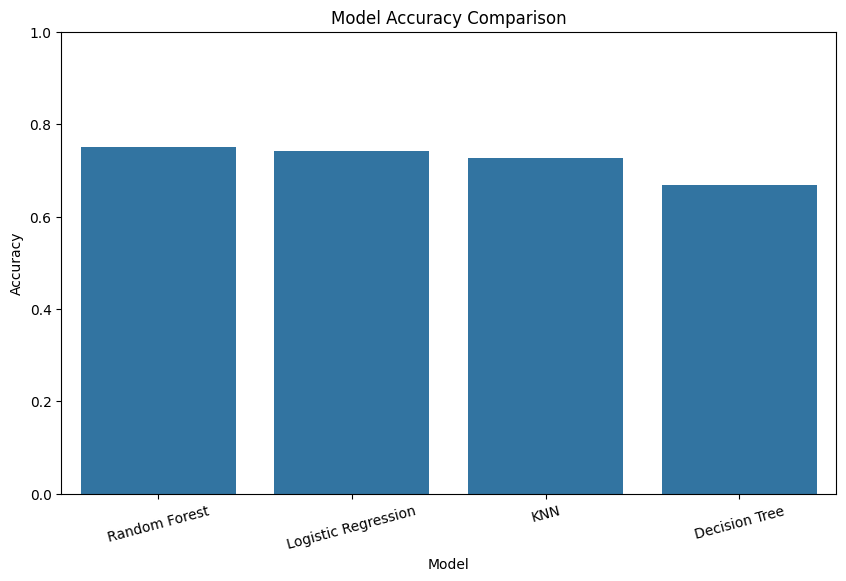

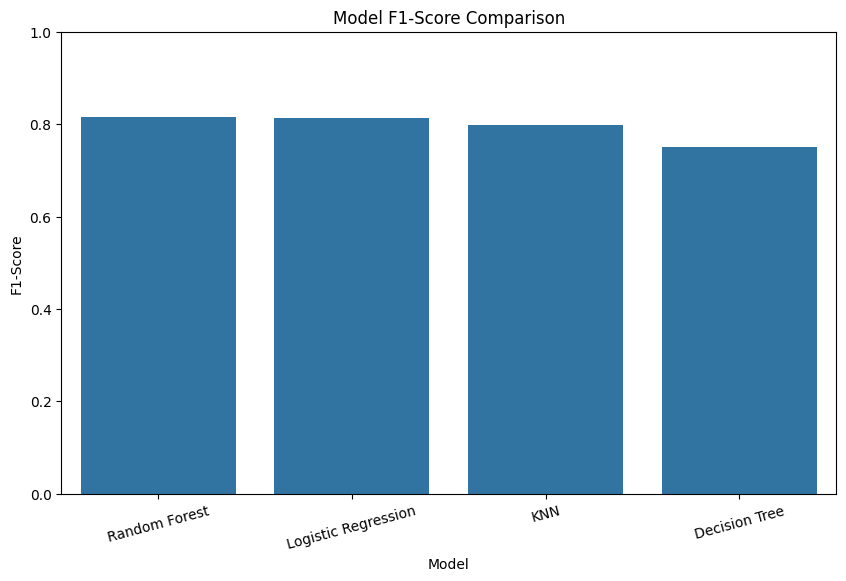

In [7]:
# -------------------------------
# 7. PLOT COMPARISON CHARTS
# -------------------------------
plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="F1-Score", data=results_df)
plt.title("Model F1-Score Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()


In [8]:
# -------------------------------
# 8. IDENTIFY BEST MODEL
# -------------------------------
best_model = results_df.iloc[0]

print("\n===== BEST MODEL =====")
print(f"Best Model   : {best_model['Model']}")
print(f"Accuracy     : {best_model['Accuracy']:.4f}")
print(f"Precision    : {best_model['Precision']:.4f}")
print(f"Recall       : {best_model['Recall']:.4f}")
print(f"F1-Score     : {best_model['F1-Score']:.4f}")



===== BEST MODEL =====
Best Model   : Random Forest
Accuracy     : 0.7516
Precision    : 0.8007
Recall       : 0.8298
F1-Score     : 0.8150


In [9]:
# -------------------------------
# 9. SHORT CONCLUSION
# -------------------------------
print("\n===== CONCLUSION =====")
print(
    f"Among the four supervised learning algorithms tested, "
    f"{best_model['Model']} achieved the best overall performance "
    f"based on accuracy. This suggests that it is the most suitable "
    f"model for predicting white wine quality in this study."
)


===== CONCLUSION =====
Among the four supervised learning algorithms tested, Random Forest achieved the best overall performance based on accuracy. This suggests that it is the most suitable model for predicting white wine quality in this study.
